In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

# 1. Download the dataset directly to your folder
url = "https://raw.githubusercontent.com/k22patel/NYC_Real_Estate_Price/main/NY-House-Dataset.csv"
urllib.request.urlretrieve(url, "NY-House-Dataset.csv" )
print("Step 1: File downloaded successfully!")

# 2. Load the dataset
df = pd.read_csv('NY-House-Dataset.csv')

# 3. Calculate Price per Sqft (Note: column name is PROPERTYSQFT)
df['PRICE_PER_SQFT'] = df['PRICE'] / df['PROPERTYSQFT']

# 4. Display first 5 rows
print("Step 2: Data loaded and processed!")
df.head()


Step 1: File downloaded successfully!
Step 2: Data loaded and processed!


,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE,PRICE_PER_SQFT
0,Brokered by Douglas Elliman -111 Fifth Ave,Condo for sale,315000,2,2.000000,1400.0,2 E 55th St Unit 803,"New York, NY 10022","2 E 55th St Unit 803New York, NY 10022",New York County,New York,Manhattan,East 55th Street,Regis Residence,"Regis Residence, 2 E 55th St #803, New York, N...",40.761255,-73.974483,225.000000
1,Brokered by Serhant,Condo for sale,195000000,7,10.000000,17545.0,Central Park Tower Penthouse-217 W 57th New Yo...,"New York, NY 10019",Central Park Tower Penthouse-217 W 57th New Yo...,United States,New York,New York County,New York,West 57th Street,"217 W 57th St, New York, NY 10019, USA",40.766393,-73.980991,11114.277572
2,Brokered by Sowae Corp,House for sale,260000,4,2.000000,2015.0,620 Sinclair Ave,"Staten Island, NY 10312","620 Sinclair AveStaten Island, NY 10312",United States,New York,Richmond County,Staten Island,Sinclair Avenue,"620 Sinclair Ave, Staten Island, NY 10312, USA",40.541805,-74.196109,129.032258
3,Brokered by COMPASS,Condo for sale,69000,3,1.000000,445.0,2 E 55th St Unit 908W33,"Manhattan, NY 10022","2 E 55th St Unit 908W33Manhattan, NY 10022",United States,New York,New York County,New York,East 55th Street,"2 E 55th St, New York, NY 10022, USA",40.761398,-73.974613,155.056180
4,Brokered by Sotheby's International Realty - E...,Townhouse for sale,55000000,7,2.373861,14175.0,5 E 64th St,"New York, NY 10065","5 E 64th StNew York, NY 10065",United States,New York,New York County,New York,East 64th Street,"5 E 64th St, New York, NY 10065, USA",40.767224,-73.969856,3880.070547


In [2]:
# Create 5 equal-width bins for Price per Sqft using NumPy
bins = np.linspace(df['PRICE_PER_SQFT'].min(), df['PRICE_PER_SQFT'].max(), 6)
df['PRICE_BIN'] = pd.cut(df['PRICE_PER_SQFT'], bins=bins, labels=[f"Bin {i}" for i in range(5)])

# Print the range for each bin
print("Price per Sqft Bins:")
for i in range(len(bins)-1):
    print(f"Bin {i}: ${bins[i]:.2f} to ${bins[i+1]:.2f}")


Price per Sqft Bins:
Bin 0: $1.14 to $42950.59
Bin 1: $42950.59 to $85900.03
Bin 2: $85900.03 to $128849.48
Bin 3: $128849.48 to $171798.92
Bin 4: $171798.92 to $214748.36


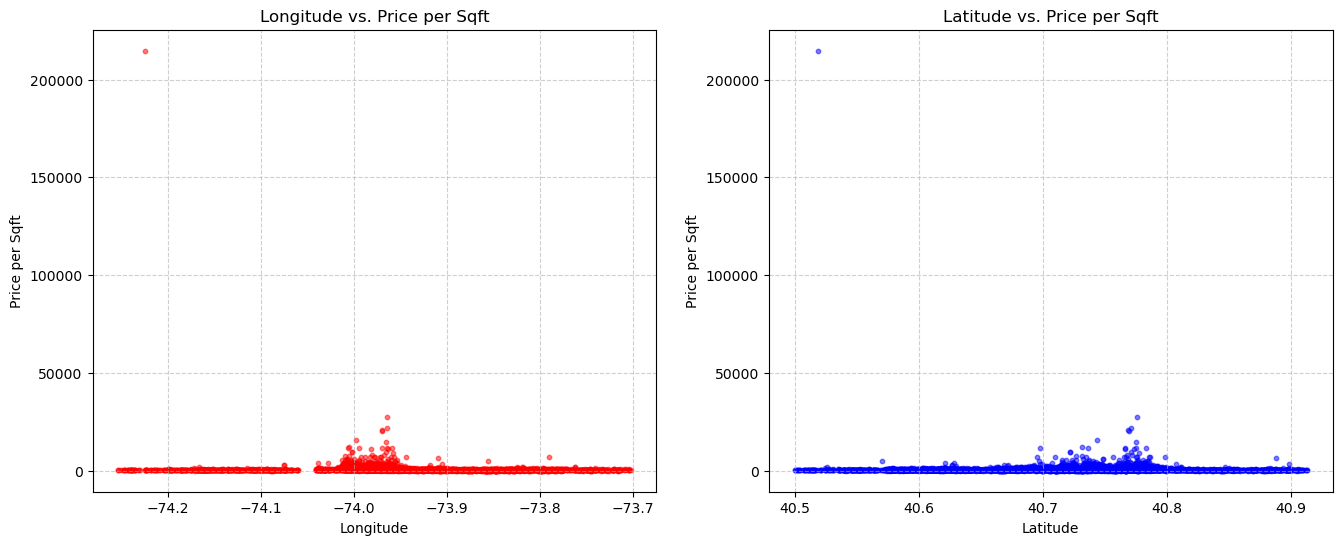

In [3]:
plt.figure(figsize=(16, 6))

# Chart 1: Longitude vs Price per Sqft (Red)
plt.subplot(1, 2, 1)
plt.scatter(df['LONGITUDE'], df['PRICE_PER_SQFT'], color='red', alpha=0.5, s=10)
plt.title('Longitude vs. Price per Sqft')
plt.xlabel('Longitude')
plt.ylabel('Price per Sqft')
plt.grid(True, linestyle='--', alpha=0.6)

# Chart 2: Latitude vs Price per Sqft (Blue)
plt.subplot(1, 2, 2)
plt.scatter(df['LATITUDE'], df['PRICE_PER_SQFT'], color='blue', alpha=0.5, s=10)
plt.title('Latitude vs. Price per Sqft')
plt.xlabel('Latitude')
plt.ylabel('Price per Sqft')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


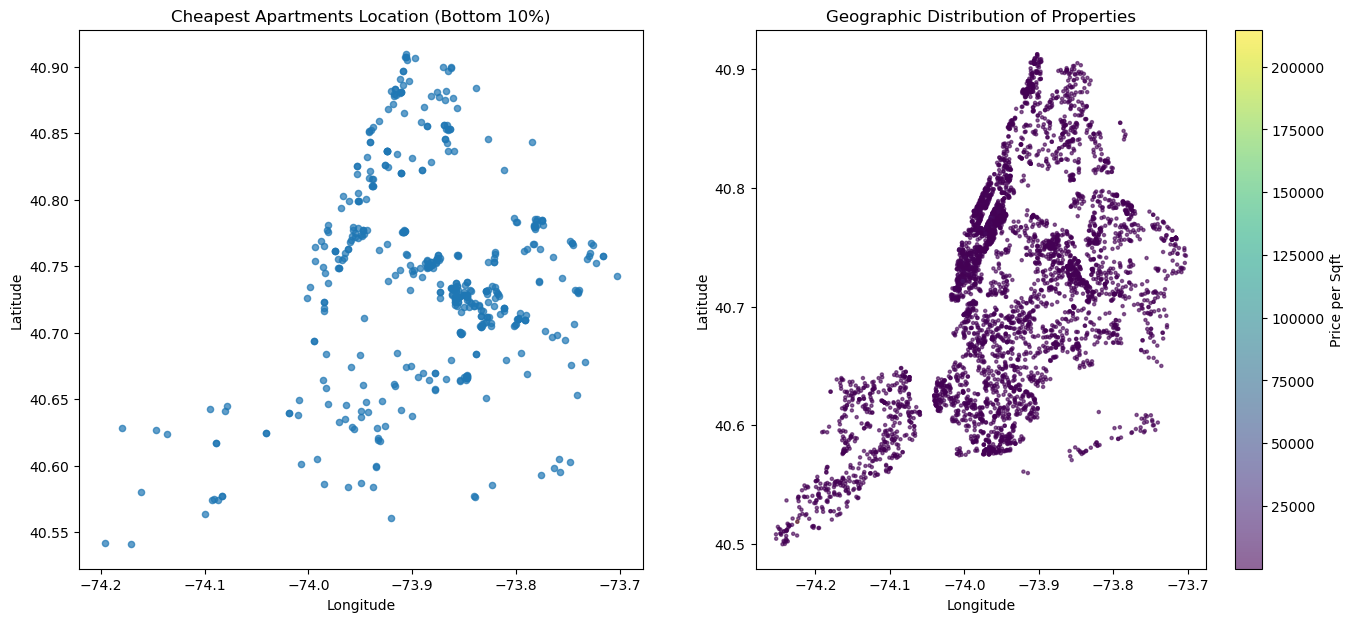

In [4]:
plt.figure(figsize=(16, 7))

# Map 1: Cheapest Apartments (Bottom 10% of the market)
plt.subplot(1, 2, 1)
cheapest_threshold = df['PRICE_PER_SQFT'].quantile(0.1)
cheapest = df[df['PRICE_PER_SQFT'] < cheapest_threshold]
plt.scatter(cheapest['LONGITUDE'], cheapest['LATITUDE'], color='tab:blue', s=20, alpha=0.7)
plt.title('Cheapest Apartments Location (Bottom 10%)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Map 2: Full Geographic Distribution (Color-coded by Price)
plt.subplot(1, 2, 2)
scatter = plt.scatter(df['LONGITUDE'], df['LATITUDE'], c=df['PRICE_PER_SQFT'], 
                      cmap='viridis', s=5, alpha=0.6)
plt.colorbar(scatter, label='Price per Sqft')
plt.title('Geographic Distribution of Properties')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()


In [5]:
# Summary of key metrics
summary_stats = {
    'Metric': ['Price', 'Property Sqft', 'Price per Sqft'],
    'Min': [df['PRICE'].min(), df['PROPERTYSQFT'].min(), df['PRICE_PER_SQFT'].min()],
    'Max': [df['PRICE'].max(), df['PROPERTYSQFT'].max(), df['PRICE_PER_SQFT'].max()]
}
summary_df = pd.DataFrame(summary_stats)
print("Project Summary Statistics:")
print(summary_df.to_string(index=False))


Project Summary Statistics:
        Metric         Min          Max
         Price 2494.000000 2.147484e+09
 Property Sqft  230.000000 6.553500e+04
Price per Sqft    1.141833 2.147484e+05
